<a href="https://colab.research.google.com/github/TiCampanha/Projeto-template/blob/main/eda_projeto_ia_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1ª Etapa do Projeto - Análise Exploratória de Dados (EDA)

### 1) Qual a base escolhida e qual seu interesse nela?

A base escolhida é a [Brazilian E-Commerce Public Dataset by Olist, disponível no Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce). Ela reúne informações anonimizadas de aproximadamente 100 mil pedidos realizados no comércio eletrônico brasileiro entre 2016 e 2018. Escolhi essa base porque permite investigar o comportamento das compras, os meios de pagamento, os custos de frete, os prazos de entrega e a satisfação dos clientes. Essas dimensões possibilitam produzir gráficos e verificar relações úteis para compreender a experiência de compra.

### 2)  Descrição básica do conjunto de dados escolhido pelo aluno (1 parágrafo).

A análise será feita no nível do pedido, combinando as tabelas de pedidos, itens, pagamentos, avaliações e clientes por seus identificadores. As variáveis principais serão: `order_status` (categórica), `price_total` e `freight_total` (contínuas), `payment_value_total` (contínua), `payment_installments` (discreta), `payment_type` (categórica), `review_score` (discreta ordinal), `delivery_days` e `delivery_delay_days` (contínuas derivadas de datas), `purchase_month` (temporal agrupada) e `customer_state` (categórica). O conjunto original possui nove arquivos CSV relacionados; o número exato de linhas e colunas das tabelas utilizadas será exibido pelo código.

### 3)  Faça uma avaliação descritiva da sua base. Quantas linhas ela possui? Quais os tipos de dados? Quantas e quais features possuem?

A base original é composta por 9 arquivos CSV relacionados, que armazenam informações sobre pedidos, itens, pagamentos, avaliações, clientes, produtos, vendedores, geolocalização e tradução de categorias. Para este projeto, foi criada uma base analítica que reúne informações de diferentes tabelas e utiliza o pedido como unidade de análise.
Na execução do notebook, a base analítica apresentou 99.441 linhas e 22 colunas (features). Cada linha representa um pedido, enquanto as colunas contêm informações que permitem investigar suas características comerciais e logísticas.


O código abaixo carrega os arquivos CSV, inspeciona dimensões e tipos, identifica valores ausentes e duplicados e realiza o pré-processamento das variáveis escolhidas. Antes de executar, baixe o conjunto de dados no Kaggle, extraia os arquivos e coloque os CSVs em uma pasta chamada `data`, no mesmo diretório deste notebook. Os nomes dos arquivos devem permanecer iguais aos originais.

In [2]:
# Bibliotecas utilizadas
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Traduções usadas apenas nas saídas; os nomes originais das colunas são mantidos
# internamente para não quebrar os cálculos.
TRADUCAO_VALORES = {
    "created": "Criado", "approved": "Aprovado", "invoiced": "Faturado",
    "processing": "Em processamento", "shipped": "Enviado",
    "delivered": "Entregue", "canceled": "Cancelado", "unavailable": "Indisponível",
    "credit_card": "Cartão de crédito", "boleto": "Boleto bancário",
    "voucher": "Vale-compra", "debit_card": "Cartão de débito",
    "not_defined": "Não definido", "SP": "São Paulo", "RJ": "Rio de Janeiro",
    "MG": "Minas Gerais", "RS": "Rio Grande do Sul", "PR": "Paraná",
    "SC": "Santa Catarina", "BA": "Bahia", "DF": "Distrito Federal",
    "ES": "Espírito Santo", "GO": "Goiás", "PE": "Pernambuco",
    "CE": "Ceará", "PA": "Pará", "MT": "Mato Grosso",
    "MA": "Maranhão", "MS": "Mato Grosso do Sul", "PB": "Paraíba",
    "PI": "Piauí", "RN": "Rio Grande do Norte", "AL": "Alagoas",
    "SE": "Sergipe", "TO": "Tocantins", "RO": "Rondônia",
    "AM": "Amazonas", "AC": "Acre", "AP": "Amapá", "RR": "Roraima",
    "Não informado": "Não informado", "Não entregue/sem data": "Não entregue/sem data",
    "Atrasado": "Atrasado", "No prazo ou antecipado": "No prazo ou antecipado"
}
TRADUCAO_COLUNAS = {
    "orders": "Pedidos", "items": "Itens", "payments": "Pagamentos",
    "reviews": "Avaliações", "customers": "Clientes", "order_status": "Status do pedido",
    "payment_type": "Tipo de pagamento", "review_score": "Nota de avaliação",
    "customer_state": "Estado do cliente", "delivery_status": "Situação da entrega",
    "price_band": "Faixa de valor", "price_total": "Valor dos itens por pedido (R$)",
    "freight_total": "Frete total por pedido (R$)",
    "payment_value_total": "Valor total pago por pedido (R$)",
    "payment_installments": "Número de parcelas", "delivery_days": "Dias entre compra e entrega",
    "delivery_delay_days": "Dias de atraso/antecipação", "item_count": "Quantidade de itens",
    "purchase_month": "Mês da compra", "order_id": "Identificador do pedido",
    "order_purchase_timestamp": "Data da compra", "order_approved_at": "Data de aprovação",
    "order_delivered_carrier_date": "Data de envio à transportadora",
    "order_delivered_customer_date": "Data de entrega ao cliente",
    "order_estimated_delivery_date": "Data estimada de entrega",
    "customer_id": "Identificador do cliente", "tabela": "Tabela", "linhas": "Linhas",
    "colunas": "Colunas", "duplicatas_completas": "Duplicatas completas",
    "total_valores_ausentes": "Total de valores ausentes", "tipo": "Tipo de dado",
    "ausentes": "Valores ausentes", "valores_ausentes": "Valores ausentes",
    "quantidade": "Quantidade", "percentual_%": "Percentual (%)",
    "relação": "Relação", "variável_x": "Variável X", "variável_y": "Variável Y",
    "n_observações": "Número de observações", "correlação_spearman": "Correlação de Spearman"
}

def traduzir_saida(obj):
    """Traduz rótulos e categorias de tabelas exibidas, sem alterar os dados originais."""
    if isinstance(obj, pd.DataFrame):
        resultado = obj.copy()
        resultado.index = resultado.index.map(lambda x: TRADUCAO_VALORES.get(str(x), str(x)) if str(x) != "nan" else "Não informado")
        resultado.columns = [TRADUCAO_COLUNAS.get(str(x), str(x)) for x in resultado.columns]
        return resultado.rename(index=TRADUCAO_COLUNAS)
    if isinstance(obj, pd.Series):
        resultado = obj.copy()
        resultado.index = resultado.index.map(lambda x: TRADUCAO_VALORES.get(str(x), str(x)) if str(x) != "nan" else "Não informado")
        resultado.name = TRADUCAO_COLUNAS.get(str(resultado.name), resultado.name)
        return resultado
    return obj

_display_original = display
def display(obj, *args, **kwargs):
    return _display_original(traduzir_saida(obj), *args, **kwargs)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = Path("data")

arquivos = {
    "orders": "olist_orders_dataset.csv",
    "items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "customers": "olist_customers_dataset.csv",
}

faltantes = [nome for nome in arquivos.values() if not (DATA_DIR / nome).exists()]
if faltantes:
    raise FileNotFoundError(
        "Arquivos não encontrados na pasta 'data': " + ", ".join(faltantes) +
        "\nBaixe o dataset no Kaggle, extraia os CSVs e coloque-os na pasta data/."
    )

orders = pd.read_csv(DATA_DIR / arquivos["orders"])
items = pd.read_csv(DATA_DIR / arquivos["items"])
payments = pd.read_csv(DATA_DIR / arquivos["payments"])
reviews = pd.read_csv(DATA_DIR / arquivos["reviews"])
customers = pd.read_csv(DATA_DIR / arquivos["customers"])

# Visão inicial: quantidade de registros, colunas e tipos em cada tabela.
resumo_tabelas = []
for nome, tabela in {
    "Pedidos": orders, "Itens": items, "Pagamentos": payments,
    "Avaliações": reviews, "Clientes": customers
}.items():
    resumo_tabelas.append({
        "tabela": nome,
        "linhas": len(tabela),
        "colunas": len(tabela.columns),
        "duplicatas_completas": int(tabela.duplicated().sum()),
        "total_valores_ausentes": int(tabela.isna().sum().sum())
    })
display(pd.DataFrame(resumo_tabelas))

print("Colunas e tipos da tabela de pedidos:")
display(orders.dtypes.rename("tipo").to_frame())
print("Valores ausentes por coluna na tabela de pedidos:")
display(orders.isna().sum().sort_values(ascending=False).rename("ausentes").to_frame())

# Conversão de datas para datetime; valores inválidos são convertidos em NaT.
colunas_data = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for coluna in colunas_data:
    orders[coluna] = pd.to_datetime(orders[coluna], errors="coerce")

# Agregação dos itens por pedido: soma de preços e fretes.
items_agg = items.groupby("order_id", as_index=False).agg(
    price_total=("price", "sum"),
    freight_total=("freight_value", "sum"),
    item_count=("order_item_id", "count")
)

# Pagamentos: soma dos valores; número máximo de parcelas e primeiro tipo registrado.
payments_agg = payments.groupby("order_id", as_index=False).agg(
    payment_value_total=("payment_value", "sum"),
    payment_installments=("payment_installments", "max"),
    payment_type=("payment_type", "first")
)

# Avaliações: média quando houver mais de uma avaliação vinculada ao pedido.
reviews_agg = reviews.groupby("order_id", as_index=False).agg(
    review_score=("review_score", "mean")
)

# Um registro de cliente por customer_id para evitar multiplicação de linhas no merge.
customers_clean = customers[["customer_id", "customer_state"]].drop_duplicates("customer_id")

df = (
    orders.merge(items_agg, on="order_id", how="left")
          .merge(payments_agg, on="order_id", how="left")
          .merge(reviews_agg, on="order_id", how="left")
          .merge(customers_clean, on="customer_id", how="left")
)

# Engenharia de atributos temporais.
df["delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.total_seconds() / 86400
df["delivery_delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400
df["purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype("string")
df["review_score"] = df["review_score"].round().astype("Int64")

# Pré-processamento: valores negativos de preço/frete/duração são tratados como inválidos.
# Em vez de excluir pedidos inteiros, esses campos ficam ausentes para as análises numéricas.
for coluna in ["price_total", "freight_total", "payment_value_total", "delivery_days"]:
    df.loc[df[coluna] < 0, coluna] = np.nan

# Faixas interpretáveis para análises de distribuição e dependência.
df["price_band"] = pd.cut(
    df["price_total"],
    bins=[-np.inf, 50, 150, 500, np.inf],
    labels=["Até R$ 50", "R$ 50–150", "R$ 150–500", "Acima de R$ 500"],
    right=False
)
df["review_group"] = pd.cut(
    df["review_score"],
    bins=[0, 2, 3, 5],
    labels=["Baixa (1–2)", "Neutra (3)", "Alta (4–5)"]
)
df["delivery_status"] = np.select(
    [
        df["order_delivered_customer_date"].isna(),
        df["delivery_delay_days"] > 0
    ],
    ["Não entregue/sem data", "Atrasado"],
    default="No prazo ou antecipado"
)

print(f"Base analítica: {df.shape[0]:,} linhas e {df.shape[1]} colunas.")
print(f"Período de compra: {df['order_purchase_timestamp'].min()} até "
      f"{df['order_purchase_timestamp'].max()}")
display(df.head())
print("Resumo descritivo das variáveis numéricas:")
display(df[[
    "price_total", "freight_total", "payment_value_total",
    "payment_installments", "review_score", "delivery_days",
    "delivery_delay_days", "item_count"
]].describe().T)

print("Valores ausentes nas variáveis de análise:")
display(df[[
    "order_status", "price_total", "freight_total", "payment_value_total",
    "payment_installments", "payment_type", "review_score",
    "delivery_days", "delivery_delay_days", "customer_state"
]].isna().sum().sort_values(ascending=False).to_frame("valores_ausentes"))


,Tabela,Linhas,Colunas,Duplicatas completas,Total de valores ausentes
0,Pedidos,99441,8,0,4908
1,Itens,112650,7,0,0
2,Pagamentos,103886,5,0,0
3,Avaliações,99224,7,0,145903
4,Clientes,99441,5,0,0


Colunas e tipos da tabela de pedidos:


,Tipo de dado
Identificador do pedido,object
Identificador do cliente,object
Status do pedido,object
Data da compra,object
Data de aprovação,object
Data de envio à transportadora,object
Data de entrega ao cliente,object
Data estimada de entrega,object


Valores ausentes por coluna na tabela de pedidos:


,Valores ausentes
Data de entrega ao cliente,2965
Data de envio à transportadora,1783
Data de aprovação,160
Identificador do pedido,0
Data da compra,0
Status do pedido,0
Identificador do cliente,0
Data estimada de entrega,0


...

,Identificador do pedido,Identificador do cliente,Status do pedido,Data da compra,Data de aprovação,Data de envio à transportadora,Data de entrega ao cliente,Data estimada de entrega,Valor dos itens por pedido (R$),Frete total por pedido (R$),Quantidade de itens,Valor total pago por pedido (R$),Número de parcelas,Tipo de pagamento,Nota de avaliação,Estado do cliente,Dias entre compra e entrega,Dias de atraso/antecipação,Mês da compra,Faixa de valor,review_group,Situação da entrega
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,1.00,38.71,1.00,credit_card,4,SP,8.44,-7.11,2017-10,Até R$ 50,Alta (4–5),No prazo ou antecipado
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,1.00,141.46,1.00,boleto,4,BA,13.78,-5.36,2018-07,R$ 50–150,Alta (4–5),No prazo ou antecipado
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,1.00,179.12,3.00,credit_card,5,GO,9.39,-17.25,2018-08,R$ 150–500,Alta (4–5),No prazo ou antecipado
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,1.00,72.20,1.00,credit_card,5,RN,13.21,-12.98,2017-11,Até R$ 50,Alta (4–5),No prazo ou antecipado
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,1.00,28.62,1.00,credit_card,5,SP,2.87,-9.24,2018-02,Até R$ 50,Alta (4–5),No prazo ou antecipado


Resumo descritivo das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
Valor dos itens por pedido (R$),"98,666.00",137.75,210.65,0.85,45.90,86.90,149.90,"13,440.00"
Frete total por pedido (R$),"98,666.00",22.82,21.65,0.00,13.85,17.17,24.04,"1,794.96"
Valor total pago por pedido (R$),"99,440.00",160.99,221.95,0.00,62.01,105.29,176.97,"13,664.08"
Número de parcelas,"99,440.00",2.93,2.72,0.00,1.00,2.00,4.00,24.00
Nota de avaliação,"98,673.00",4.09,1.35,1.00,4.00,5.00,5.00,5.00
Dias entre compra e entrega,"96,476.00",12.56,9.55,0.53,6.77,10.22,15.72,209.63
Dias de atraso/antecipação,"96,476.00",-11.18,10.19,-146.02,-16.24,-11.95,-6.39,188.98
Quantidade de itens,"98,666.00",1.14,0.54,1.00,1.00,1.00,1.00,21.00


Valores ausentes nas variáveis de análise:


,Valores ausentes
Dias entre compra e entrega,2965
Dias de atraso/antecipação,2965
Frete total por pedido (R$),775
Valor dos itens por pedido (R$),775
Nota de avaliação,768
Tipo de pagamento,1
Valor total pago por pedido (R$),1
Número de parcelas,1
Status do pedido,0
Estado do cliente,0


### 4)  Nos blocos seguintes construa análises que vão justificar suas conclusões.

#### 4.1) Análise 1 -  Distribuição dos valores para cada uma das variáveis
- Exemplo para variável contínua: se o conjunto de dados possui a variável "idade". Quantos % possui a idade entre 0 e 30 anos? 31 a 59? 60+?

- Exemplo para variável discreta: se o conjunto de dados possui a variável "gênero", quantos % do conjunto de dados é do sexo feminino, quantos % é masculino? Inclua outros gêneros se houver.


Serão apresentadas distribuições para as variáveis numéricas e categóricas selecionadas. Valores monetários serão resumidos por faixas para facilitar a leitura, enquanto status, meios de pagamento, notas e estados serão apresentados por frequência e percentual.


Distribuição de Status do pedido:


,Quantidade,Percentual (%)
order_status,,
Entregue,96478,97.02
Enviado,1107,1.11
Cancelado,625,0.63
Indisponível,609,0.61
Faturado,314,0.32
Em processamento,301,0.30
Criado,5,0.01
Aprovado,2,0.00



Distribuição de Tipo de pagamento:


,Quantidade,Percentual (%)
payment_type,,
Cartão de crédito,75387,75.81
Boleto bancário,19784,19.90
Vale-compra,2739,2.75
Cartão de débito,1527,1.54
Não definido,3,0.00
Não informado,1,0.00



Distribuição de Nota de avaliação:


...

,Quantidade,Percentual (%)
customer_state,,
São Paulo,41746,41.98
Rio de Janeiro,12852,12.92
Minas Gerais,11635,11.70
Rio Grande do Sul,5466,5.50
Paraná,5045,5.07
Santa Catarina,3637,3.66
Bahia,3380,3.40
Distrito Federal,2140,2.15
Espírito Santo,2033,2.04



Distribuição de Situação da entrega:


,Quantidade,Percentual (%)
delivery_status,,
No prazo ou antecipado,88649,89.15
Atrasado,7827,7.87
Não entregue/sem data,2965,2.98



Distribuição de Faixa de valor:


,Quantidade,Percentual (%)
price_band,,
R$ 50–150,45020,45.27
Até R$ 50,29393,29.56
R$ 150–500,20612,20.73
Acima de R$ 500,3641,3.66
Não informado,775,0.78


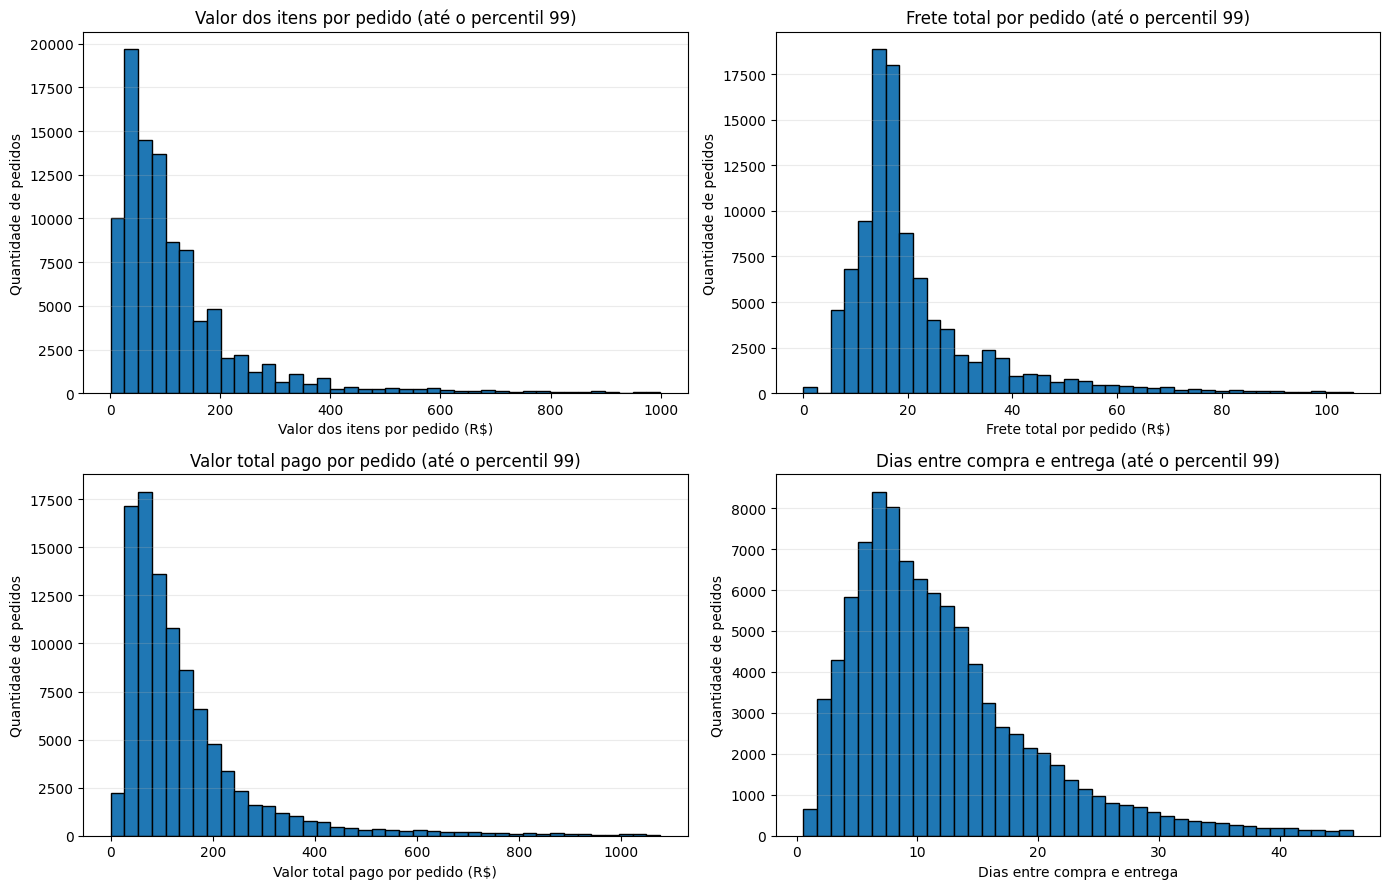

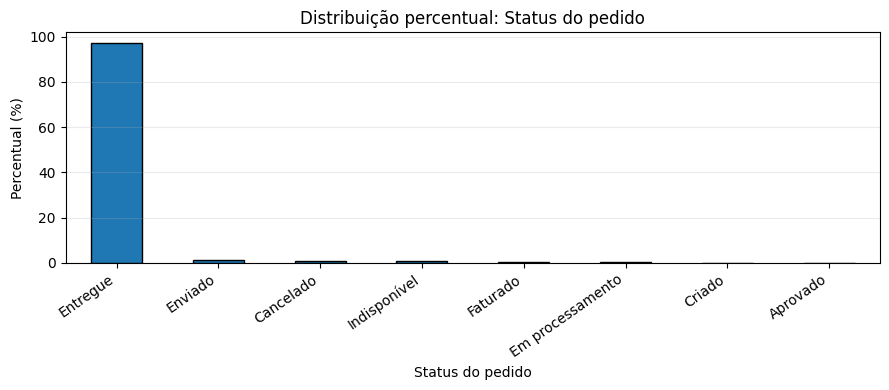

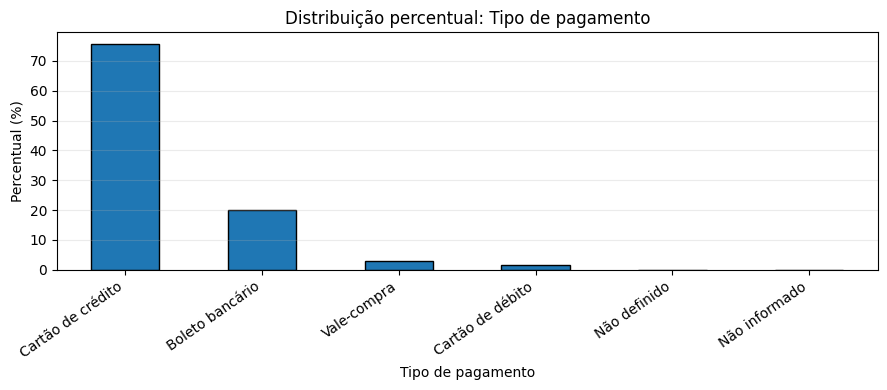

TypeError: Invalid value 'Não informado' for dtype Int64

In [3]:
# Funções auxiliares para apresentar contagens e percentuais.
def tabela_frequencia(dados, coluna):
    # Convertemos temporariamente para string se for categórica para evitar problemas no fillna/replace
    valores = dados[coluna].astype(str) if isinstance(dados[coluna].dtype, pd.CategoricalDtype) else dados[coluna]
    freq = valores.value_counts(dropna=False)
    resultado = pd.DataFrame({
        "quantidade": freq,
        "percentual_%": (freq / len(dados) * 100).round(2)
    })
    return resultado

variaveis_categoricas = [
    "order_status", "payment_type", "review_score",
    "customer_state", "delivery_status", "price_band"
]
for coluna in variaveis_categoricas:
    print(f"\nDistribuição de {TRADUCAO_COLUNAS.get(coluna, coluna)}:")
    display(tabela_frequencia(df, coluna).rename(index=TRADUCAO_VALORES))

# Histogramas de variáveis contínuas; os quantis evitam que poucos extremos dominem a escala.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, coluna, titulo in zip(
    axes.flat,
    ["price_total", "freight_total", "payment_value_total", "delivery_days"],
    ["Valor dos itens por pedido", "Frete total por pedido",
     "Valor total pago por pedido", "Dias entre compra e entrega"]
):
    serie = df[coluna].dropna()
    if not serie.empty:
        limite = serie.quantile(0.99)
        ax.hist(serie[serie <= limite], bins=40, edgecolor="black")
    ax.set_title(titulo + " (até o percentil 99)")
    ax.set_xlabel(TRADUCAO_COLUNAS.get(coluna, coluna))
    ax.set_ylabel("Quantidade de pedidos")
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Barras com percentuais para variáveis categóricas selecionadas.
for coluna in ["order_status", "payment_type", "review_score", "delivery_status"]:
    valores = df[coluna].astype(str) if isinstance(df[coluna].dtype, pd.CategoricalDtype) else df[coluna]
    percentuais = valores.fillna("Não informado").replace("nan", "Não informado").replace(TRADUCAO_VALORES).value_counts(normalize=True).mul(100)
    plt.figure(figsize=(9, 4))
    percentuais.plot(kind="bar", edgecolor="black")
    plt.title(f"Distribuição percentual: {TRADUCAO_COLUNAS.get(coluna, coluna)}")
    plt.ylabel("Percentual (%)")
    plt.xlabel(TRADUCAO_COLUNAS.get(coluna, coluna))
    plt.xticks(rotation=35, ha="right")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

# Distribuição temporal do número de pedidos por mês.
pedidos_mes = df.groupby("purchase_month", dropna=False).size()
plt.figure(figsize=(13, 4))
pedidos_mes.plot(kind="line", marker="o")
plt.title("Quantidade de pedidos por mês")
plt.xlabel("Mês da compra")
plt.ylabel("Número de pedidos")
plt.xticks(rotation=60)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 4.2) Análise 2 - Dependência entre variáveis

Para estudar a dependência entre variáveis, a nota de avaliação será agrupada em três níveis: baixa (1–2), neutra (3) e alta (4–5). Em seguida, serão comparadas as distribuições de meios de pagamento, faixas de valor do pedido e situação de atraso entre esses níveis. A comparação mostra associações descritivas, mas não demonstra causalidade.


Distribuição percentual de Tipo de pagamento dentro de cada grupo de avaliação:


,Boleto bancário,Cartão de crédito,Cartão de débito,Não definido,Não informado,Vale-compra
review_group,,,,,,
Baixa (1–2),19.56,75.85,1.37,0.01,0.01,3.20
Neutra (3),20.62,74.95,1.44,0.01,0.00,2.97
Alta (4–5),19.89,75.89,1.59,0.00,0.00,2.64


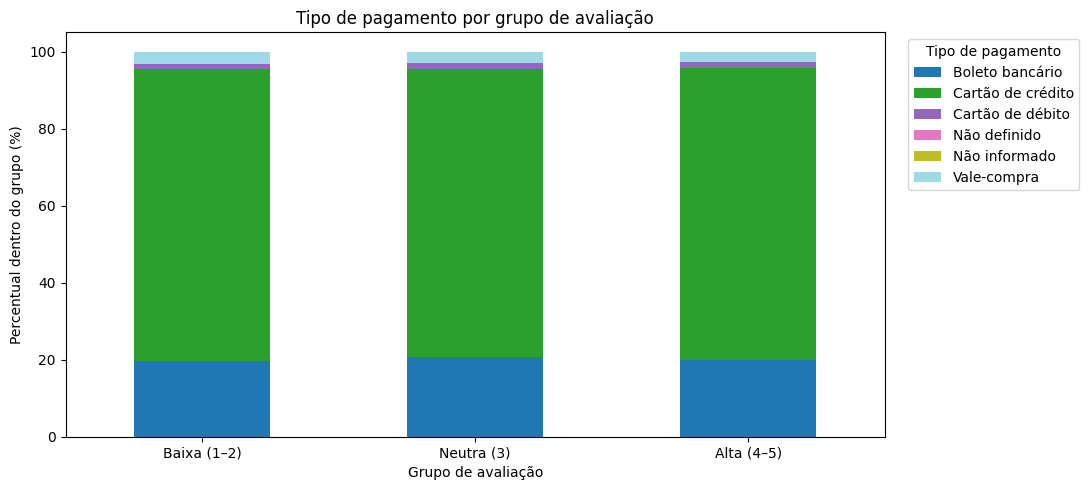


Distribuição percentual de Faixa de valor dentro de cada grupo de avaliação:


,Acima de R$ 500,Até R$ 50,Não informado,R$ 150–500,R$ 50–150
review_group,,,,,
Baixa (1–2),4.87,24.74,4.15,23.73,42.51
Neutra (3),2.94,30.98,0.65,20.35,45.08
Alta (4–5),3.49,30.37,0.13,20.17,45.84


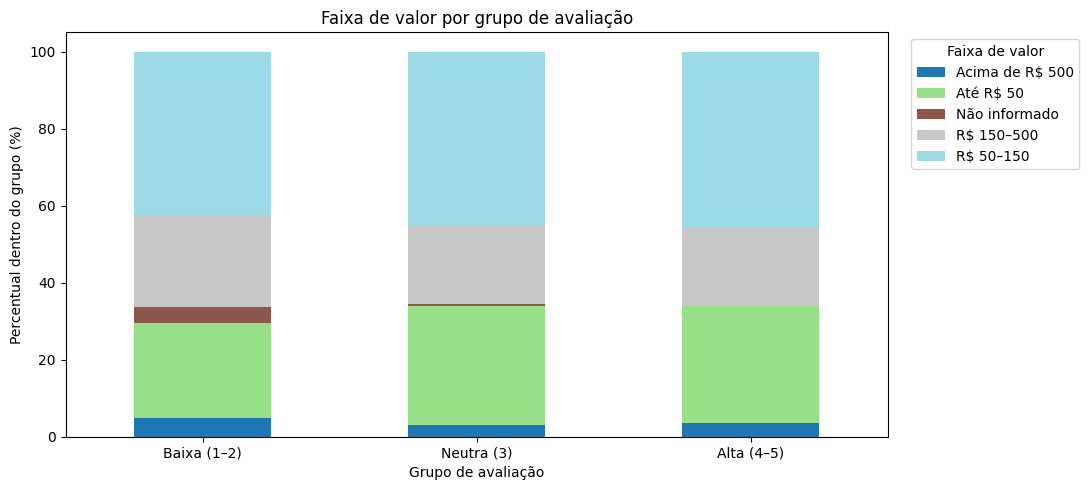


Distribuição percentual de Situação da entrega dentro de cada grupo de avaliação:


,Atrasado,No prazo ou antecipado,Não entregue/sem data
review_group,,,
Baixa (1–2),28.60,56.12,15.28
Neutra (3),10.68,86.62,2.70
Alta (4–5),3.49,95.98,0.54


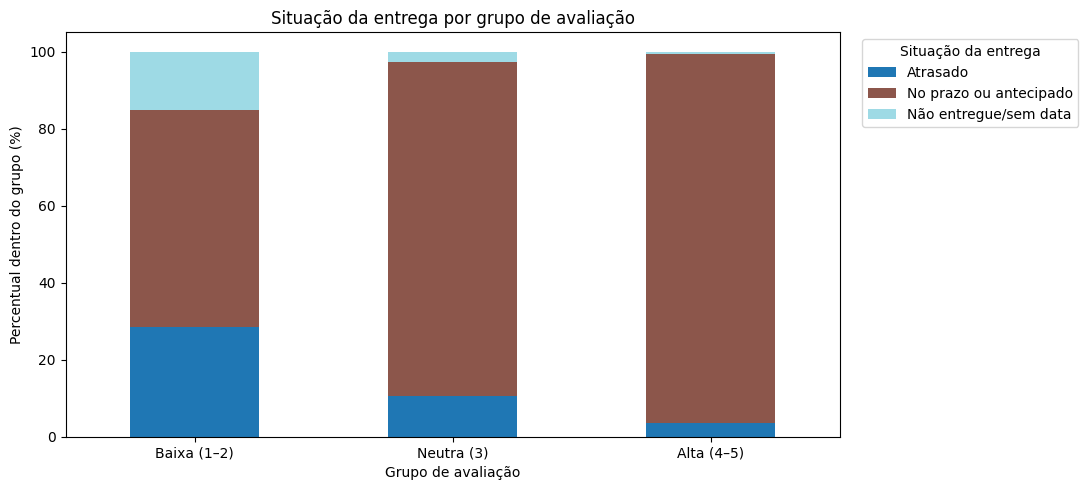

/tmp/ipykernel_1360/1375285448.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grupos, labels=["Baixa (1–2)", "Neutra (3)", "Alta (4–5)"])


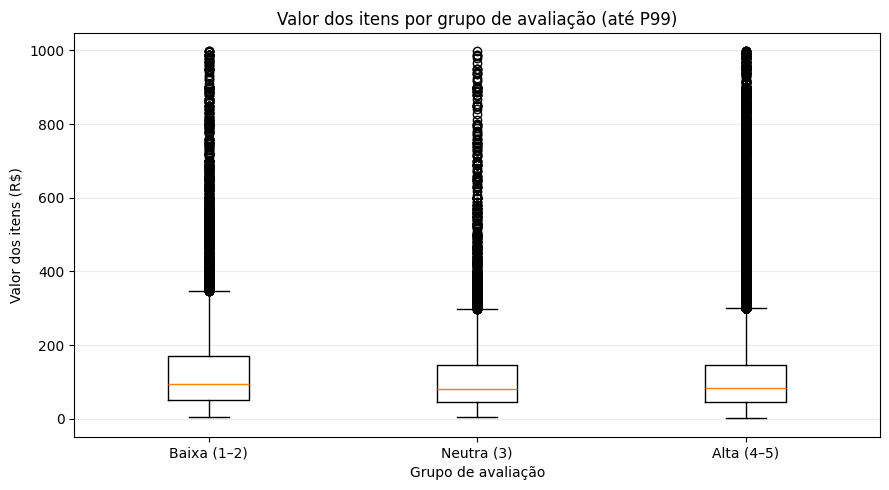

In [4]:
# Distribuições condicionais: percentuais dentro de cada grupo de avaliação.
df_dep = df.dropna(subset=["review_group"]).copy()

for coluna in ["payment_type", "price_band", "delivery_status"]:
    # Convertemos temporariamente para string se for do tipo Categorical para evitar o erro de categoria inexistente
    valores_coluna = df_dep[coluna].astype(str) if isinstance(df_dep[coluna].dtype, pd.CategoricalDtype) else df_dep[coluna]

    tab = pd.crosstab(
        df_dep["review_group"],
        valores_coluna.fillna("Não informado").replace("nan", "Não informado").replace(TRADUCAO_VALORES),
        normalize="index"
    ).mul(100).round(2)
    print(f"\nDistribuição percentual de {TRADUCAO_COLUNAS.get(coluna, coluna)} dentro de cada grupo de avaliação:")
    display(tab)

    ax = tab.plot(kind="bar", stacked=True, figsize=(11, 5), colormap="tab20")
    ax.set_title(f"{TRADUCAO_COLUNAS.get(coluna, coluna)} por grupo de avaliação")
    ax.set_xlabel("Grupo de avaliação")
    ax.set_ylabel("Percentual dentro do grupo (%)")
    ax.legend(title=TRADUCAO_COLUNAS.get(coluna, coluna), bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Comparação de valores por grupo de avaliação (remove extremos acima do percentil 99 para o gráfico).
plot_df = df_dep.dropna(subset=["price_total", "review_group"]).copy()
if not plot_df.empty:
    limite = plot_df["price_total"].quantile(0.99)
    plot_df = plot_df[plot_df["price_total"] <= limite]
    grupos = [
        plot_df.loc[plot_df["review_group"] == grupo, "price_total"].dropna()
        for grupo in df_dep["review_group"].cat.categories
    ]
    plt.figure(figsize=(9, 5))
    plt.boxplot(grupos, labels=["Baixa (1–2)", "Neutra (3)", "Alta (4–5)"])
    plt.title("Valor dos itens por grupo de avaliação (até P99)")
    plt.xlabel("Grupo de avaliação")
    plt.ylabel("Valor dos itens (R$)")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

#### 4.3) Análise 3 - Correlação entre variáveis

Serão examinadas três relações: valor total dos itens versus frete total; duração da entrega versus nota de avaliação; e valor total do pagamento versus número de parcelas. Para as relações numéricas será calculada a correlação de Spearman, que mede associação monotônica e é menos sensível a distribuições assimétricas do que a correlação de Pearson. Gráficos de dispersão e/ou boxplots complementarão os coeficientes.

Valor dos itens × frete total: rho de Spearman = 0.469 (n = 98,666)
Duração da entrega × nota de avaliação: rho de Spearman = -0.235 (n = 95,830)
Valor pago × número de parcelas: rho de Spearman = 0.382 (n = 99,440)


,Relação,Variável X,Variável Y,Número de observações,Correlação de Spearman
0,Valor dos itens × frete total,Valor dos itens por pedido (R$),Frete total por pedido (R$),98666,0.47
1,Duração da entrega × nota de avaliação,Dias entre compra e entrega,Nota de avaliação,95830,-0.23
2,Valor pago × número de parcelas,Valor total pago por pedido (R$),Número de parcelas,99440,0.38


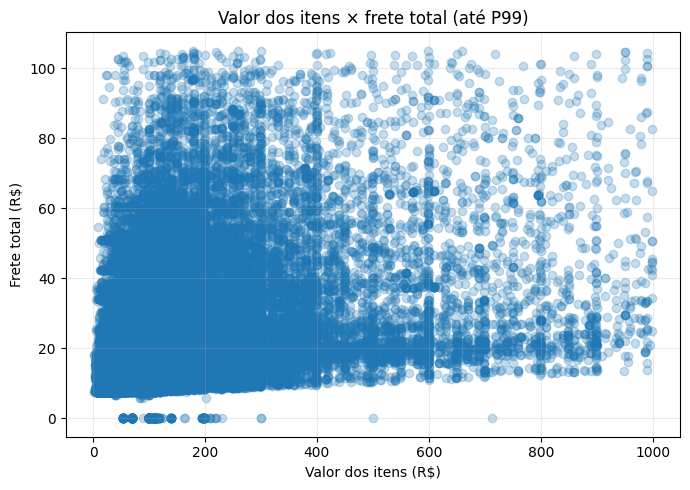

<Figure size 800x500 with 0 Axes>

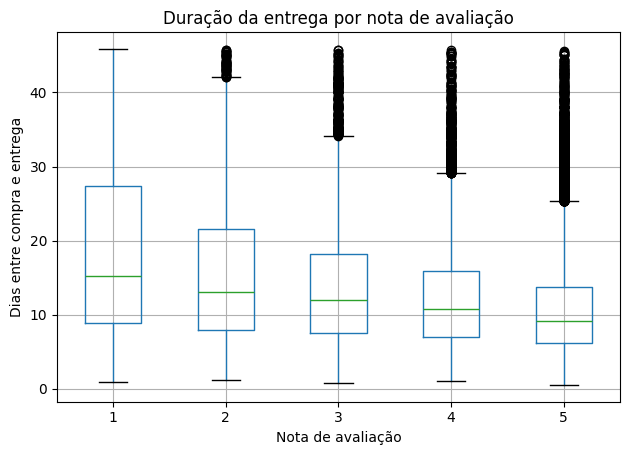

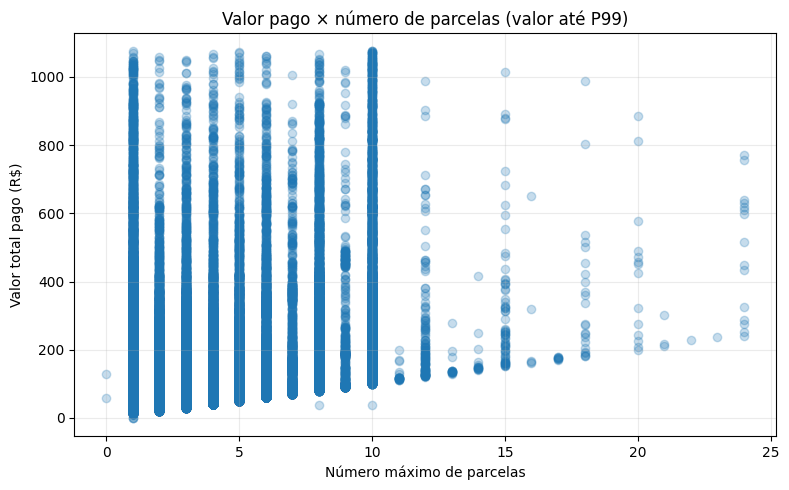

In [5]:
# Correlações de Spearman para três pares de variáveis.
pares = [
    ("price_total", "freight_total", "Valor dos itens × frete total"),
    ("delivery_days", "review_score", "Duração da entrega × nota de avaliação"),
    ("payment_value_total", "payment_installments", "Valor pago × número de parcelas")
]

resultados_corr = []
for x, y, descricao in pares:
    par_df = df[[x, y]].dropna()
    coef = par_df[x].corr(par_df[y], method="spearman") if len(par_df) >= 2 else np.nan
    resultados_corr.append({
        "relação": descricao,
        "variável_x": TRADUCAO_COLUNAS.get(x, x),
        "variável_y": TRADUCAO_COLUNAS.get(y, y),
        "n_observações": len(par_df),
        "correlação_spearman": coef
    })
    print(f"{descricao}: rho de Spearman = {coef:.3f} (n = {len(par_df):,})")

display(pd.DataFrame(resultados_corr))

# Visualizações dos pares. O corte no percentil 99 melhora a legibilidade, sem alterar
# os dados usados no cálculo dos coeficientes acima.
# 1) Valor dos itens e frete.
plot_df = df[["price_total", "freight_total"]].dropna()
if not plot_df.empty:
    plot_df = plot_df[
        (plot_df["price_total"] <= plot_df["price_total"].quantile(0.99)) &
        (plot_df["freight_total"] <= plot_df["freight_total"].quantile(0.99))
    ]
    plt.figure(figsize=(7, 5))
    plt.scatter(plot_df["price_total"], plot_df["freight_total"], alpha=0.25)
    plt.title("Valor dos itens × frete total (até P99)")
    plt.xlabel("Valor dos itens (R$)")
    plt.ylabel("Frete total (R$)")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

# 2) Duração da entrega e nota de avaliação.
plot_df = df[["delivery_days", "review_score"]].dropna()
if not plot_df.empty:
    plot_df = plot_df[plot_df["delivery_days"] <= plot_df["delivery_days"].quantile(0.99)]
    plt.figure(figsize=(8, 5))
    plot_df.boxplot(column="delivery_days", by="review_score")
    plt.suptitle("")
    plt.title("Duração da entrega por nota de avaliação")
    plt.xlabel("Nota de avaliação")
    plt.ylabel("Dias entre compra e entrega")
    plt.tight_layout()
    plt.show()

# 3) Valor total pago e número de parcelas.
plot_df = df[["payment_value_total", "payment_installments"]].dropna()
if not plot_df.empty:
    plot_df = plot_df[plot_df["payment_value_total"] <= plot_df["payment_value_total"].quantile(0.99)]
    plt.figure(figsize=(8, 5))
    plt.scatter(plot_df["payment_installments"], plot_df["payment_value_total"], alpha=0.25)
    plt.title("Valor pago × número de parcelas (valor até P99)")
    plt.xlabel("Número máximo de parcelas")
    plt.ylabel("Valor total pago (R$)")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


### 5) Conclusões

*As conclusões finais serão geradas a partir dos resultados exibidos durante a execução do notebook. Ao interpretar os resultados, diferencie associação de causalidade, informe limitações causadas por dados ausentes e considere que os registros representam o período de 2016 a 2018, não o mercado atual.

In [6]:
# Apoio para redigir conclusões com base nos resultados calculados.
print("RESUMO PARA AS CONCLUSÕES")
print("- Total de pedidos na base analítica:", f"{len(df):,}")
print("- Pedidos entregues:", f"{(df['order_status'] == 'delivered').sum():,}")
print("- Percentual com avaliação disponível:", f"{df['review_score'].notna().mean() * 100:.2f}%")
print("- Nota média:", round(df["review_score"].mean(), 2))
print("- Valor mediano dos itens por pedido (R$):", round(df["price_total"].median(), 2))
print("- Frete mediano por pedido (R$):", round(df["freight_total"].median(), 2))
print("- Duração mediana da entrega (dias):", round(df["delivery_days"].median(), 2))
print("- Percentual de entregas atrasadas entre pedidos com data de entrega:",
      f"{(df.loc[df['order_delivered_customer_date'].notna(), 'delivery_delay_days'].gt(0).mean() * 100):.2f}%")

print(
    "\nInterprete esses números junto dos gráficos e da tabela de correlações. "
    "Registre no texto de conclusão os principais padrões observados, os possíveis impactos "
    "para a experiência do cliente e as limitações da análise. Não afirme causalidade apenas "
    "com base em correlações."
)


RESUMO PARA AS CONCLUSÕES
- Total de pedidos na base analítica: 99,441
- Pedidos entregues: 96,478
- Percentual com avaliação disponível: 99.23%
- Nota média: 4.09
- Valor mediano dos itens por pedido (R$): 86.9
- Frete mediano por pedido (R$): 17.17
- Duração mediana da entrega (dias): 10.22
- Percentual de entregas atrasadas entre pedidos com data de entrega: 8.11%

Interprete esses números junto dos gráficos e da tabela de correlações. Registre no texto de conclusão os principais padrões observados, os possíveis impactos para a experiência do cliente e as limitações da análise. Não afirme causalidade apenas com base em correlações.
